# 神经网络（Neural Network）

用 TensorFlow / Keras 搭建并训练一个基础神经网络，完整走一遍：**数据准备 → 搭建模型 → 编译 → 训练 → 评估与预测 → 可视化**。

- 任务：XOR（异或）问题 —— 两个特征相同输出 0，不同输出 1
- 结构：2 个输入 → 3 个隐藏神经元（sigmoid）→ 1 个输出（sigmoid）
- 关键点：异或问题是**线性不可分**的，单个逻辑回归无法拟合，必须依靠隐藏层做特征变换


## 0. 前置知识：激活函数与损失函数

| 激活函数 | 公式 | 适用位置 | 特点 |
| --- | --- | --- | --- |
| sigmoid | 1/(1+exp(-z)) | 二分类输出层、隐藏层 | 输出 (0,1) 概率，深层网络容易梯度消失 |
| ReLU | max(0, z) | 隐藏层 | 计算简单、速度快，但可能让部分神经元输出恒为 0（神经元死亡） |
| 线性 | z | 回归输出层 | 输出可正可负 |

损失函数：

- 回归任务 → 均方误差 `mse`（标签 y 可正可负）
- 二分类任务 → 二元交叉熵 `binary_crossentropy`（配合 sigmoid 输出的概率）


## 1. 数据准备：XOR 异或问题

异或规则：判断 x1、x2 是否都大于 0.5 —— 两者相同为 0，不同为 1。

在 [0,1] × [0,1] 的正方形区域内均匀采样，再按规则打标签：

```
X = uniform(0, 1, size=(n, 2))
y = (x1 > 0.5) XOR (x2 > 0.5)      # 结果 0 / 1
```

四个角点 (0,0)→0、(0,1)→1、(1,0)→1、(1,1)→0 就是标准异或真值表，训练完成后用它检查预测结果。


In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 固定随机种子，保证每次运行采样结果一致
np.random.seed(1)
n_samples = 1000

# 特征矩阵：形状 (1000, 2)，每一行是一个样本的两个特征
X = np.random.uniform(0, 1, size=(n_samples, 2))

# 标签：异或规则，形状 (1000, 1)，二分类用 0/1 表示
y = ((X[:, 0] > 0.5) ^ (X[:, 1] > 0.5)).astype(np.float32).reshape(-1, 1)

# 异或的 4 个角点，训练完成后用来直观检查预测结果
xor_points = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)

print('X shape:', X.shape, '| y shape:', y.shape)
print('标签为 1 的样本数:', int(y.sum()), '| 标签为 0 的样本数:', int(len(y) - y.sum()))

X shape: (1000, 2) | y shape: (1000, 1)
标签为 1 的样本数: 515 | 标签为 0 的样本数: 485


## 2. 搭建模型

- **Sequential**：按顺序堆叠的线性结构，前一层的输出就是后一层的输入
- **Dense（全连接层）**：内部做 `z = W·a_in + b`，再把 z 交给激活函数

| 层 | 神经元数 | 激活函数 | 说明 |
| --- | --- | --- | --- |
| 隐藏层 | 3 | sigmoid | `input_shape=(2,)` 由第一层声明输入维度；异或至少需要 2 个隐藏神经元 |
| 输出层 | 1 | sigmoid | 二分类只要 1 个输出，值即「标签为 1 的概率」 |

参数量：隐藏层 2×3+3=9，输出层 3×1+1=4，共 13 个可训练参数（即需要梯度下降去学习的 W 和 b）。


In [5]:
# 搭建模型：2 → 3 → 1
model = tf.keras.Sequential([
    # 隐藏层：3 个神经元，sigmoid 激活
    tf.keras.layers.Dense(3, activation='sigmoid', input_shape=(2,)),

    # 输出层：1 个神经元，sigmoid 激活，输出「标签为 1 的概率」
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 打印网络结构（每层输出形状、参数量）
model.summary()

# 想画网络结构图需要额外安装 graphviz / pydot，这里先注释掉：
# tf.keras.utils.plot_model(model, show_shapes=True, to_file='neural_network.png')

c:\ProgramData\Anaconda3\envs\python3.13\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 编译：指定损失函数、优化器、评估指标

```
model.compile(loss='binary_crossentropy',   # 二分类交叉熵
              optimizer=Adam(lr=0.1),       # 自适应学习率的优化器
              metrics=['accuracy'])         # 训练时额外打印准确率
```

学习率的影响：太大容易震荡甚至发散，太小收敛很慢。


In [6]:
model.compile(
    # 损失函数：二元交叉熵（输出层是 sigmoid 概率，必须配它；回归才用 mse）
    loss='binary_crossentropy',

    # 优化器：Adam 自适应学习率，比原始梯度下降收敛更快
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),

    # 评估指标：训练过程中额外打印准确率，方便观察拟合情况
    metrics=['accuracy']
)

## 4. 训练

`fit` 会重复执行 epochs 次下面的循环：

```
前向传播 → 计算损失 → 反向传播求梯度 → 更新 W 和 b
```

参数含义：

- `epochs`：整个数据集过多少遍，太少欠拟合、太多容易过拟合
- `batch_size`：每批样本数，权重每处理完一个 batch 更新一次
- `verbose=0`：不打印过程，避免 1000 轮刷屏

返回值 `history` 保存了每一轮的 loss 和 accuracy，后面用来画学习曲线。


In [ ]:
# ---- GPU 加速说明（NVIDIA 显卡）----
# 1) Keras 会自动把计算放到可用的 GPU 上，下面这段训练代码不需要任何改动
# 2) 检查是否识别到 GPU（返回 [] 说明当前装的是 CPU 版 TensorFlow）：
#        print(tf.config.list_physical_devices('GPU'))
# 3) 想显式指定在 GPU 上训练：
#        with tf.device('/GPU:0'):
#            history = model.fit(X, y, epochs=1000, batch_size=32)
# 4) 原生 Windows 上 TensorFlow >= 2.11 不支持 GPU（即使装了 CUDA 也不会启用），
#    只支持到 tensorflow 2.10 + CUDA 11.2 + cuDNN 8.1，且需要 Python 3.9/3.10；
#    版本不匹配时能看到 'GPU support is not available on native Windows' 警告。
#    想在高版本 TensorFlow 上用 GPU 需要改用 WSL2：
#        pip install "tensorflow[and-cuda]"
# 5) 本例只有 1000 个样本、13 个可训练参数，计算量太小，
#    GPU 的核函数启动和数据拷贝开销大于计算本身，通常不会比 CPU 快、甚至更慢；
#    样本量上万、batch_size 调大、或换成卷积网络后 GPU 才有明显优势
history = model.fit(
    X, y,
    epochs=1000,
    batch_size=32,
    verbose=0
)

print('训练结束：loss={:.4f}，accuracy={:.4f}'.format(
    history.history['loss'][-1], history.history['accuracy'][-1]))

训练结束：loss=0.1244，accuracy=0.9440


## 5. 评估与预测

- `evaluate`：只做前向传播，计算编译时指定的损失和指标，**不更新参数**
- `predict`：前向传播得到预测概率，形状 (n, 1)
- 判决：概率 ≥ 0.5 判为正类 1，否则为 0


In [8]:
# 评估：在训练数据上计算损失和准确率
test_loss, test_acc = model.evaluate(X, y, verbose=0)
print('评估结果：loss={:.4f}，accuracy={:.4f}'.format(test_loss, test_acc))

# 预测 4 个异或角点
probs = model.predict(xor_points, verbose=0)

print('XOR 四个角点的预测：')
for point, prob in zip(xor_points, probs.ravel()):
    label = 1 if prob >= 0.5 else 0                      # 概率阈值判决
    truth = int(point[0] > 0.5) ^ int(point[1] > 0.5)    # 异或真值
    print('  {} -> 概率 {:.4f}，预测 {}，真实 {}'.format(point.astype(int), prob, label, truth))

评估结果：loss=0.0937，accuracy=0.9600
XOR 四个角点的预测：
  [0 0] -> 概率 0.9984，预测 1，真实 0
  [0 1] -> 概率 1.0000，预测 1，真实 1
  [1 0] -> 概率 1.0000，预测 1，真实 1
  [1 1] -> 概率 0.0034，预测 0，真实 0


## 6. 可视化：学习曲线与决策边界

- **左图（学习曲线）**：loss 应持续下降并趋于平稳，accuracy 持续上升
- **右图（决策边界）**：在整个平面上铺网格、逐点预测概率，颜色深浅表示「标签为 1 的概率」。异或的边界会呈现**十字形**，这是线性模型画不出来的形状


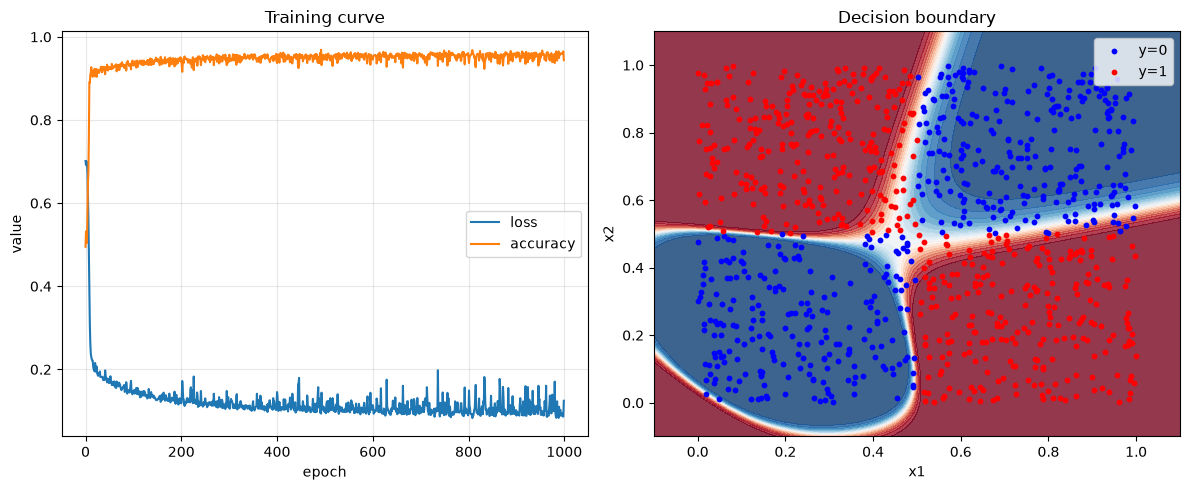

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左图：学习曲线，观察是否收敛
ax1.plot(history.history['loss'], label='loss')
ax1.plot(history.history['accuracy'], label='accuracy')
ax1.set_xlabel('epoch')
ax1.set_ylabel('value')
ax1.set_title('Training curve')
ax1.legend()
ax1.grid(alpha=0.3)

# 右图：决策边界
xx, yy = np.meshgrid(np.linspace(-0.1, 1.1, 200), np.linspace(-0.1, 1.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]                  # 拼成 (40000, 2) 的输入矩阵
zz = model.predict(grid, verbose=0).reshape(xx.shape) # 每个网格点属于类 1 的概率

ax2.contourf(xx, yy, zz, levels=20, cmap='RdBu_r', alpha=0.8)
ax2.scatter(X[y.ravel() == 0][:, 0], X[y.ravel() == 0][:, 1], c='blue', s=10, label='y=0')
ax2.scatter(X[y.ravel() == 1][:, 0], X[y.ravel() == 1][:, 1], c='red', s=10, label='y=1')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Decision boundary')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. 小结

1. 一个全连接层 = 线性变换 + 激活函数，多层堆叠就得到神经网络
2. 二分类：输出层 1 个神经元配 sigmoid，损失用 `binary_crossentropy`
3. 隐藏层的作用是**特征变换**——正是它让异或这种线性不可分问题变得可分
4. 可调超参数：`epochs`、`batch_size`、`learning_rate`、隐藏层神经元数与激活函数
5. 验证方式：看 loss 是否收敛、4 个角点是否预测正确、决策边界是否符合预期形状
